In [1]:
# Use num_env or mend_env
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import gc
from data_utilities import clean_dir_from_blanks, process_data
from plot_temuujin_df import plot_mean_df_scatter, plot_mean_df, return_random_samples, take_n_random_samples

In [5]:
# July datas
area_df_p4_july = pd.read_csv('./Processed_datas_July/area_df_dji_p4_july.csv')
averages_p4_july = pd.read_csv('./Processed_datas_July/averages_dji_p4_july.csv')

In [53]:
# # August datas
area_df_p4_august = pd.read_csv('./Processed_datas_August/area_df_4land_dji_p4_august.csv')
averages_p4_august = pd.read_csv('./Processed_datas_August/averages_dji_p4_august.csv')

In [4]:
# October datas
area_df_p4_october = pd.read_csv('./Processed_datas_October/area_df_dji_p4_october.csv')
averages_p4_october = pd.read_csv('./Processed_datas_October/averages_dji_p4_october.csv')

# best_altum_october_df = pd.read_csv('Results_Altum_October/CSV/1_best_october_data.csv')
# good_altum_october_df = pd.read_csv('./Results_Altum_October/CSV/2_good_october_data.csv')
# medium_altum_october_df = pd.read_csv('./Results_Altum_October/CSV/3_medium_october_data.csv')
# bad_altum_october_df = pd.read_csv('./Results_Altum_October/CSV/4_bad_october_data.csv')
# worst_altum_october_df = pd.read_csv('./Results_Altum_October/CSV/5_worst_october_data.csv')

area_df_altum_october = pd.read_csv('./Processed_datas_October/area_df_altum_october.csv')

In [5]:
area_df_p4_august

,Unnamed: 0,patch_number,VegetationIndex,Patch_Area,VI_Area,Pure_GaborArea,AreaSum,Unknown_Area,class,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area
0,0,256_512_2560_2816,MSAVI,65536,34919,6962.0,41881.0,23655.0,best,0.532822,0.106232,0.360947
1,1,256_512_2816_3072,MSAVI,65536,34994,9451.0,44445.0,21091.0,best,0.533966,0.144211,0.321823
2,2,256_512_3072_3328,MSAVI,65536,32344,4809.0,37153.0,28383.0,best,0.493530,0.073380,0.433090
3,3,256_512_3328_3584,MSAVI,65536,33018,9702.0,42720.0,22816.0,best,0.503815,0.148041,0.348145
4,4,256_512_3584_3840,MSAVI,65536,39399,7136.0,46535.0,19001.0,best,0.601181,0.108887,0.289932
...,...,...,...,...,...,...,...,...,...,...,...,...
4315,4315,8960_9216_6144_6400,MSAVI,65536,41776,18299.0,60075.0,5461.0,worst,0.637451,0.279221,0.083328
4316,4316,8960_9216_6400_6656,MSAVI,65536,37556,13375.0,50931.0,14605.0,worst,0.573059,0.204086,0.222855
4317,4317,8960_9216_6656_6912,MSAVI,65536,29395,23110.0,52505.0,13031.0,worst,0.448532,0.352631,0.198837
4318,4318,8960_9216_6912_7168,MSAVI,65536,34346,27843.0,62189.0,3347.0,worst,0.524078,0.424850,0.051071


In [13]:
averages_p4_july

,VI_Area,Pure_GaborArea,AreaSum,Unknown_Area,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area
class,,,,,,,
bad,36022.455289,10857.097019,46879.552309,18656.303916,0.549660,0.165666,0.284673
best,37107.054601,7044.276036,44151.330637,21384.387260,0.566211,0.107488,0.326301
good,39704.335548,7129.565615,46833.901163,18701.558140,0.605845,0.108789,0.285366
medium,45219.668735,3465.966641,48685.635376,16849.948798,0.690002,0.052887,0.257111
worst,40601.908633,10022.585612,50624.494245,14911.292086,0.619538,0.152933,0.227529


Data cleaning.

In [22]:
# Split the dataframes based on 'VI_Thresh' field into zeros and nonzeros
# This was unnecessary, but I did it anyway

def split_by_vi_threshold(df):
    zeros = df[df['VI_Thresh'] == 0]
    nonzeros = df[df['VI_Thresh'] != 0]
    return zeros, nonzeros

def find_target_zeros(df):
    zeros = df
    zeros = zeros.loc[1::2]
    zeros = zeros[['patch', 'start_vert', 'end_vert', 'start_horiz', 'end_horiz']]
    return zeros
# Split best_altum_october_df
best_altum_october_zeros, best_altum_october_nonzeros = split_by_vi_threshold(best_altum_october_df)

# Split good_altum_october_df
good_altum_october_zeros, good_altum_october_nonzeros = split_by_vi_threshold(good_altum_october_df)

# Split medium_altum_october_df
medium_altum_october_zeros, medium_altum_october_nonzeros = split_by_vi_threshold(medium_altum_october_df)

# Split bad_altum_october_df
bad_altum_october_zeros, bad_altum_october_nonzeros = split_by_vi_threshold(bad_altum_october_df)

# Split worse_altum_october_df
worst_altum_october_zeros, worse_altum_october_nonzeros = split_by_vi_threshold(worst_altum_october_df)

In [13]:
gabor_results_dir = "/media/razydave/01DA189A333B1070/MendeFolder/08_BelceeriinDoroitol/Results_Altum_October/Gabor_Results"

clean_dir_from_blanks(gabor_results_dir, find_target_zeros(best_altum_october_zeros))

Targets found: 0
Targets found: 0
Targets found: 0
Targets found: 0
Finished job.


In [16]:
clean_dir_from_blanks(gabor_results_dir, find_target_zeros(good_altum_october_zeros))

Targets found: 0
Targets found: 0
Targets found: 0
Targets found: 0
Finished job.


Turns out `altum` option sets the invokement for more intelligent data processing.

In [26]:
# df_dict = [best_altum_october_df, good_altum_october_df, medium_altum_october_df, bad_altum_october_df, worst_altum_october_df]
df_dict = {
    'best': best_altum_october_df,
    'good': good_altum_october_df,
    'medium': medium_altum_october_df,
    'bad': bad_altum_october_df,
    'worst': worst_altum_october_df
}
processed_dfs = [process_data(df, key) for key, df in df_dict.items()]

In [27]:
area_df_altum_october = pd.concat(processed_dfs, axis=0, ignore_index=True)

In [28]:
area_df_altum_october.to_csv('./Processed_datas_October/area_df_altum_october.csv', index=False)

100%|██████████| 5/5 [00:10<00:00,  2.16s/it]


{'Cbest,600,300': (0, 127, 0), 'Cbest,200,300': (0, 191, 0), 'Cbest,50,300': (0, 255, 0), 'Cbad,600,300': (0, 0, 127), 'Cbad,200,300': (63, 63, 255), 'Cbad,50,300': (191, 191, 255), 'Cmedium,600,300': (127, 127, 0), 'Cmedium,200,300': (191, 191, 0), 'Cmedium,50,300': (255, 255, 0), 'Cgood,600,300': (31, 31, 31), 'Cgood,200,300': (95, 95, 95), 'Cgood,50,300': (159, 159, 159), 'Cworst,600,300': (127, 0, 0), 'Cworst,200,300': (255, 63, 63), 'Cworst,50,300': (255, 191, 191)}


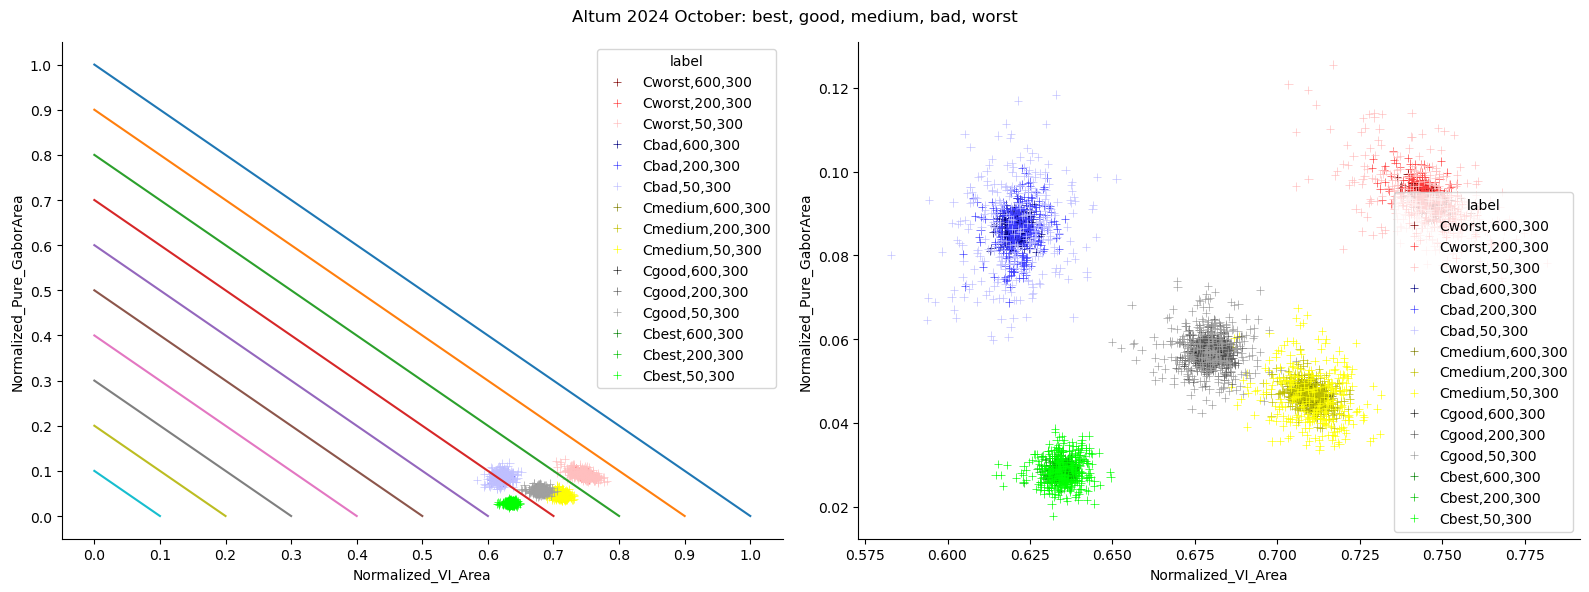

In [31]:
# 5 area plot
mean_df_altum_october, colors_normalized = return_random_samples(area_df_altum_october,  'Normalized_VI_Area', 'Normalized_Pure_GaborArea', 
                                target_classes = ['worst', 'bad','medium', 'good', 'best'], 
                                all_N = [300]*5, 
                                all_sample_sizes = [600, 200, 50])
plot_mean_df_scatter(mean_df_altum_october,  'Normalized_VI_Area', 'Normalized_Pure_GaborArea', colors_normalized, 'label', 
                     title = 'Altum 2024 October: best, good, medium, bad, worst')

100%|██████████| 5/5 [00:09<00:00,  1.93s/it]


{'Cbest,600,300': (0, 127, 0), 'Cbest,200,300': (0, 191, 0), 'Cbest,50,300': (0, 255, 0), 'Cbad,600,300': (0, 0, 127), 'Cbad,200,300': (63, 63, 255), 'Cbad,50,300': (191, 191, 255), 'Cmedium,600,300': (127, 127, 0), 'Cmedium,200,300': (191, 191, 0), 'Cmedium,50,300': (255, 255, 0), 'Cgood,600,300': (31, 31, 31), 'Cgood,200,300': (95, 95, 95), 'Cgood,50,300': (159, 159, 159), 'Cworst,600,300': (127, 0, 0), 'Cworst,200,300': (255, 63, 63), 'Cworst,50,300': (255, 191, 191)}


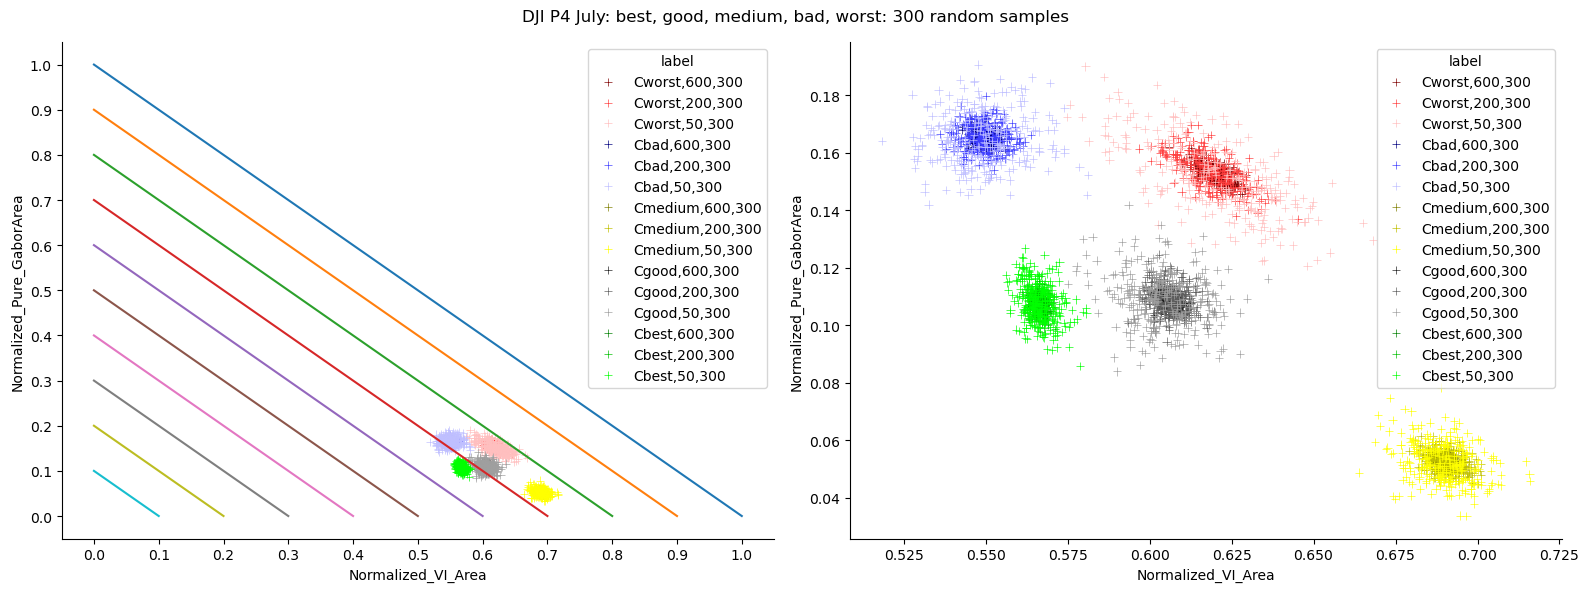

In [40]:
# 5 area plot
mean_df_p4_july, colors_normalized = return_random_samples(area_df_p4_july,  'Normalized_VI_Area', 'Normalized_Pure_GaborArea', 
                                target_classes = ['worst', 'bad','medium', 'good', 'best'], 
                                all_N = [300]*5, 
                                all_sample_sizes = [600, 200, 50])
plot_mean_df_scatter(mean_df_p4_july,  'Normalized_VI_Area', 'Normalized_Pure_GaborArea', colors_normalized, 'label', 
                     title = 'DJI P4 July: best, good, medium, bad, worst: 300 random samples')

In [38]:
area_df_p4_august['class'].value_counts()

bad      1425
worst    1058
good      989
best      848
Name: class, dtype: int64

100%|██████████| 4/4 [00:06<00:00,  1.71s/it]


{'Cbest,600,300': (0, 127, 0), 'Cbest,200,300': (0, 191, 0), 'Cbest,50,300': (0, 255, 0), 'Cbad,600,300': (0, 0, 127), 'Cbad,200,300': (63, 63, 255), 'Cbad,50,300': (191, 191, 255), 'Cgood,600,300': (31, 31, 31), 'Cgood,200,300': (95, 95, 95), 'Cgood,50,300': (159, 159, 159), 'Cworst,600,300': (127, 0, 0), 'Cworst,200,300': (255, 63, 63), 'Cworst,50,300': (255, 191, 191)}


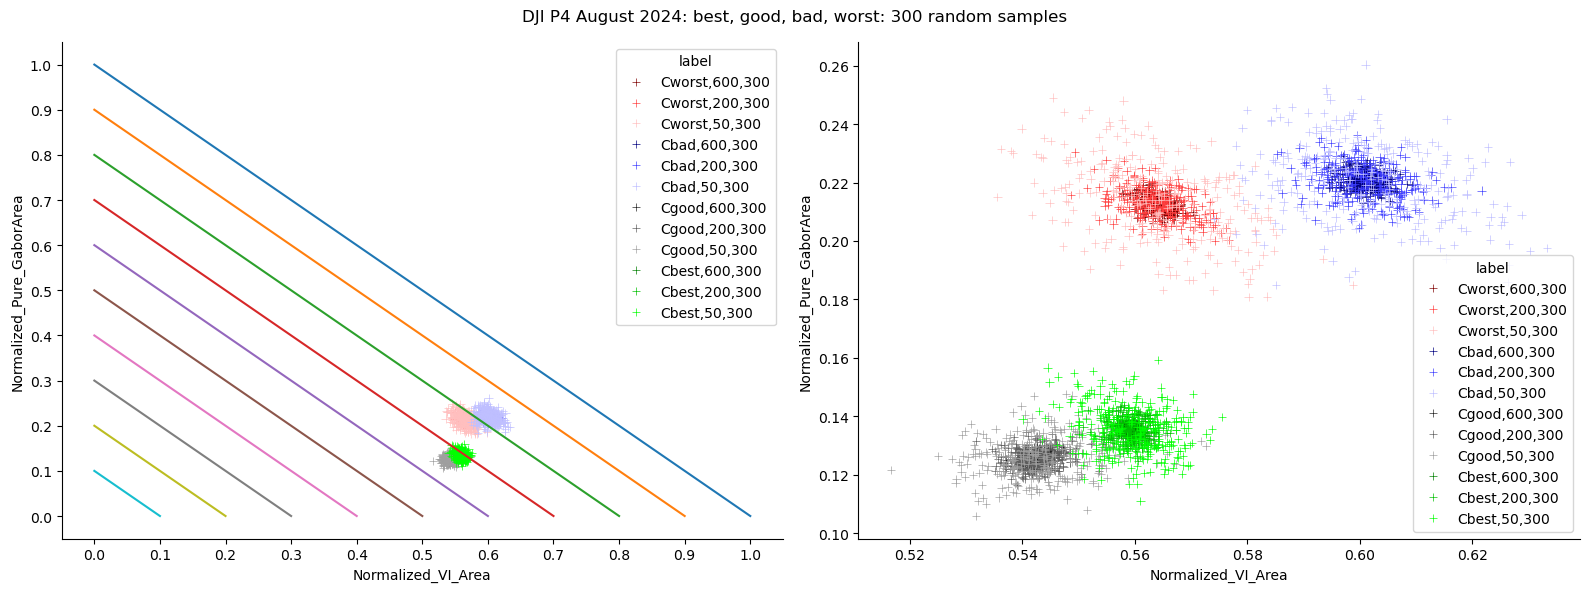

In [41]:
# 5 area plot
mean_df_p4_august, colors_normalized = return_random_samples(area_df_p4_august,  'Normalized_VI_Area', 'Normalized_Pure_GaborArea', 
                                target_classes = ['worst', 'bad', 'good', 'best'], 
                                all_N = [300]*5, 
                                all_sample_sizes = [600, 200, 50])
plot_mean_df_scatter(mean_df_p4_august,  'Normalized_VI_Area', 'Normalized_Pure_GaborArea', colors_normalized, 'label', 
                     title = 'DJI P4 August 2024: best, good, bad, worst: 300 random samples')

In [53]:
# my arguments:
averages_p4_october.columns

Index(['VI_Area', 'Pure_GaborArea', 'AreaSum', 'Unknown_Area',
       'Normalized_VI_Area', 'Normalized_Pure_GaborArea',
       'Normalized_Unknown_Area'],
      dtype='object')

In [52]:
area_df_p4_october.groupby('class')[['VI_Area','Pure_GaborArea','AreaSum','Unknown_Area','Normalized_VI_Area','Normalized_Pure_GaborArea','Normalized_Unknown_Area']].mean(numeric_only=True)

AreaSum means it's a bad parameters $\alpha$

In [20]:
averages_p4_august = area_df_p4_august.groupby('class')[['VI_Area','Pure_GaborArea','AreaSum',
                                                         'Unknown_Area','Normalized_VI_Area',
                                                         'Normalized_Pure_GaborArea',
                                                         'Normalized_Unknown_Area']].mean(
                                                             numeric_only=True).reset_index()
averages_p4_october = area_df_p4_october.groupby('class')[['VI_Area','Pure_GaborArea','AreaSum',
                                                            'Unknown_Area','Normalized_VI_Area',
                                                            'Normalized_Pure_GaborArea',
                                                            'Normalized_Unknown_Area']].mean(
                                                                numeric_only=True).reset_index()
averages_altum_october = area_df_altum_october.groupby('class')[['VI_Area','Pure_GaborArea','AreaSum',
                                                            'Unknown_Area','Normalized_VI_Area',
                                                            'Normalized_Pure_GaborArea',
                                                            'Normalized_Unknown_Area']].mean(
                                                                numeric_only=True).reset_index()
averages_p4_july = area_df_p4_july.groupby('class')[['VI_Area','Pure_GaborArea','AreaSum',
                                                            'Unknown_Area','Normalized_VI_Area',
                                                            'Normalized_Pure_GaborArea',
                                                            'Normalized_Unknown_Area']].mean(
                                                                numeric_only=True).reset_index()


In [28]:
averages_p4_october

,class,VI_Area,Pure_GaborArea,AreaSum,Unknown_Area,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area
0,bad,42206.737560,7767.872392,49974.609952,15560.792937,0.644030,0.118530,0.237441
1,best,38969.890031,5226.762590,44196.652621,21338.535457,0.594640,0.079755,0.325605
2,good,42749.949378,5955.575934,48705.525311,16830.237344,0.652315,0.090875,0.256810
3,medium,40869.012534,4491.632945,45360.645479,20174.596240,0.623619,0.068537,0.307844
4,worst,38237.865217,14399.928696,52637.793913,12897.956522,0.583466,0.219727,0.196808


In [21]:
averages_altum_october

,class,VI_Area,Pure_GaborArea,AreaSum,Unknown_Area,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area
0,bad,40679.092253,5682.222222,46361.314475,19173.233945,0.620725,0.086706,0.292570
1,best,41600.865445,1880.133923,43480.999368,22053.819962,0.634789,0.028689,0.336522
2,good,44529.736820,3734.537657,48264.274477,17270.381590,0.679480,0.056986,0.263534
3,medium,46517.235718,3065.642343,49582.878060,15951.607777,0.709808,0.046779,0.243413
4,worst,48843.383434,6125.019079,54968.402513,10566.507213,0.745302,0.093462,0.161236


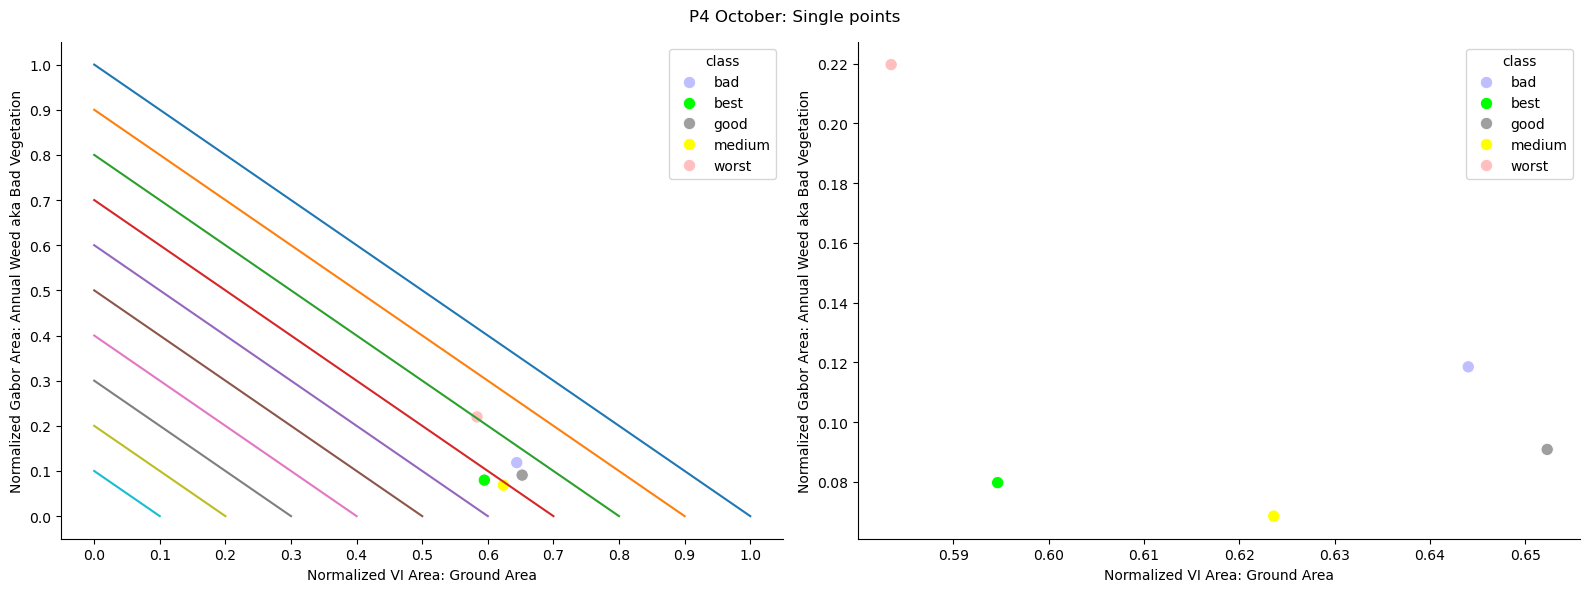

In [27]:
target_classes = ['worst', 'bad', 'medium', 'good', 'best']
colors = {
        # Best ~~ 10
        f'{target_classes[-1]}': (0, 127, 0), 
        f'{target_classes[-1]}': (0, 191, 0), 
        f'{target_classes[-1]}': (0, 255, 0),
        #'d ~~ 9
        f'{target_classes[1]}': (0, 0, 127), # blue
        f'{target_classes[1]}': (63, 63, 255), 
        f'{target_classes[1]}': (191, 191, 255),

        #'edium ~~ 2
        f'{target_classes[2]}': (127, 127, 0),  # Yellow with increasing saturation
        f'{target_classes[2]}': (191, 191, 0), 
        f'{target_classes[2]}': (255, 255, 0),

        #'od~~ 4
        f'{target_classes[-2]}': (31, 31, 31),  # Black with increasing saturation (darker grays)
        f'{target_classes[-2]}': (95, 95, 95), 
        f'{target_classes[-2]}': (159, 159, 159),
        #' medium arrives, add.
        #'orst ~~ 5
        f'{target_classes[0]}': (127, 0, 0),  # red
        f'{target_classes[0]}': (255, 63, 63), 
        f'{target_classes[0]}': (255, 191, 191),
        
    }
colors_normalized_local = {key: tuple(val / 255 for val in rgb) for key, rgb in colors.items()}

title = "P4 October: Single points"

fig, (ax1, ax2) = plt.subplots(1, 2, num=1, clear=False, figsize=(16, 6))

for ax in (ax1, ax2):
    # ax.set_xlim(0, 1)
    # ax.set_ylim(0, 1)
    ax.set_xlabel('Normalized VI Area: Ground Area')
    ax.set_ylabel('Normalized Gabor Area: Annual Weed aka Bad Vegetation')
    # ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    sns.scatterplot(data=averages_p4_october, x='Normalized_VI_Area', y='Normalized_Pure_GaborArea', hue='class', palette=colors_normalized_local, ax=ax, s=80)
    
ax1.set_xticks(np.arange(0, 1.1, 0.1))
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax1.spines[['top', 'right']].set_visible(False)
ax2.spines[['top', 'right']].set_visible(False)

for i in np.arange(1.0, 0, -0.1):
    ax1.plot([0, i], [i, 0])

plt.suptitle(title)
fig.tight_layout()

In [24]:
help(pd.concat)

Help on function concat in module pandas.core.reshape.concat:

concat(objs: 'Iterable[NDFrame] | Mapping[HashableT, NDFrame]', *, axis: 'Axis' = 0, join: 'str' = 'outer', ignore_index: 'bool' = False, keys=None, levels=None, names=None, verify_integrity: 'bool' = False, sort: 'bool' = False, copy: 'bool' = True) -> 'DataFrame | Series'
    Concatenate pandas objects along a particular axis.
    
    Allows optional set logic along the other axes.
    
    Can also add a layer of hierarchical indexing on the concatenation axis,
    which may be useful if the labels are the same (or overlapping) on
    the passed axis number.
    
    Parameters
    ----------
    objs : a sequence or mapping of Series or DataFrame objects
        If a mapping is passed, the sorted keys will be used as the `keys`
        argument, unless it is passed, in which case the values will be
        selected (see below). Any None objects will be dropped silently unless
        they are all None in which case a V

In [44]:
averages_p4_august.head()

,Unnamed: 0,class,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area,VegetationIndex,Patch_Area
0,0,bad,0.600904,0.220513,0.178583,MSAVI,65536
1,1,best,0.559351,0.135365,0.305284,MSAVI,65536
2,2,good,0.542630,0.125768,0.331602,MSAVI,65536
3,3,worst,0.564056,0.212650,0.223295,MSAVI,65536


In [74]:
columns = averages_p4_august.columns # Skipp unnamed 0 ?

filler_medium = pd.DataFrame([["0.0", 'medium', 0, 0, 0, 'MSAVI' , 0]], columns=columns)

In [75]:
filler_medium

,Unnamed: 0,class,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area,VegetationIndex,Patch_Area,Month
0,0,0.0,medium,0,0,0,MSAVI,0


In [70]:
averages_p4_august = pd.concat([averages_p4_august, filler_medium], ignore_index=True)

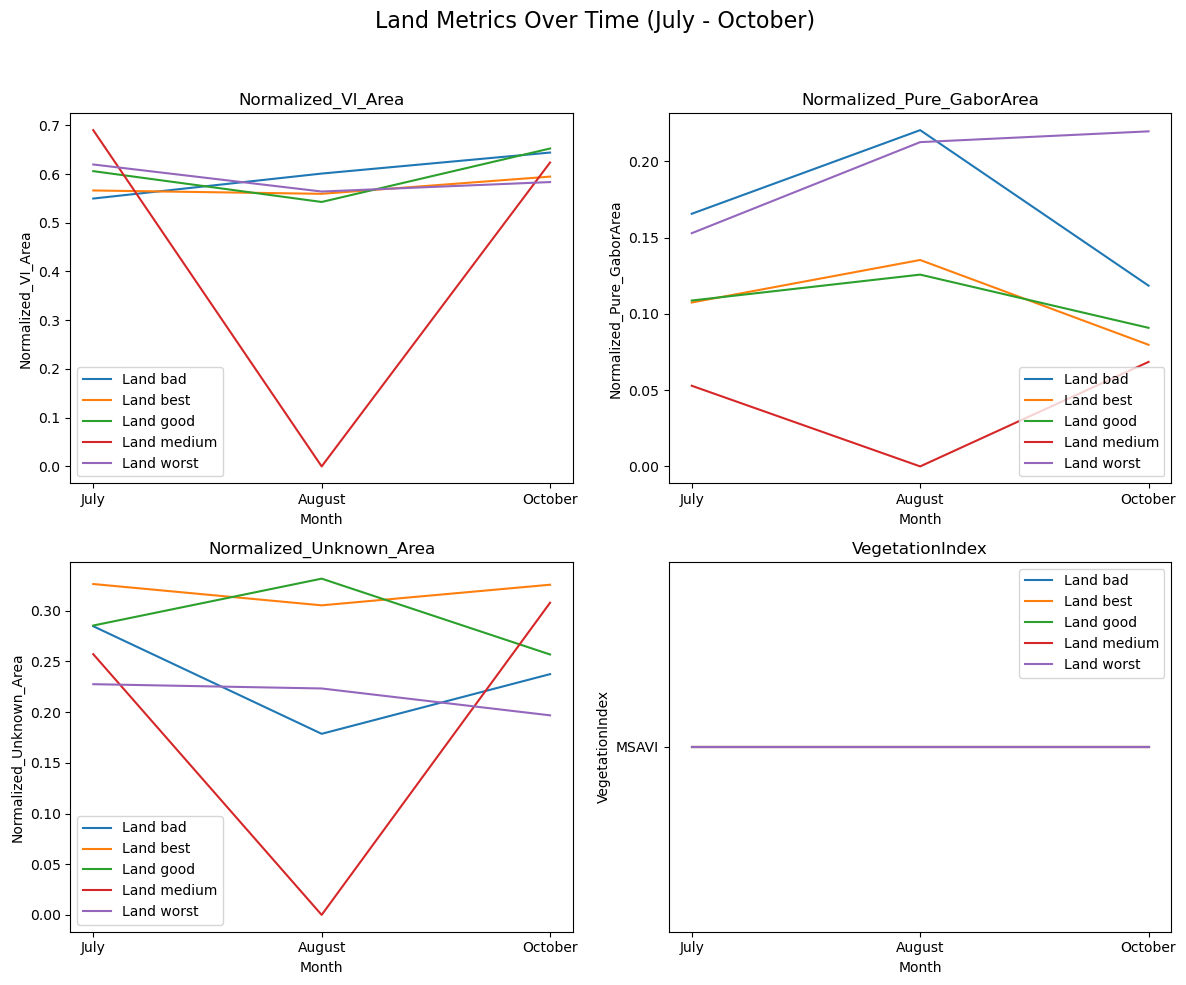

In [72]:
from IPython.display import display, HTML

# ChatGPT code:
# Load each month's data
# done

# Combine the data, adding a 'Month' column to each for easier plotting
averages_p4_july['Month'] = 'July'
averages_p4_august['Month'] = 'August'
averages_p4_october['Month'] = 'October'

# Concatenate into a single DataFrame
combined_df = pd.concat([averages_p4_july, averages_p4_august, averages_p4_october])

# Set up the figure and axis for subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Land Metrics Over Time (July - October)', fontsize=16)

# Define the metrics we want to plot
metrics = ['Normalized_VI_Area', 'Normalized_Pure_GaborArea', 'Normalized_Unknown_Area', 'VegetationIndex']
months = ['July', 'August', 'October']

# Loop through each metric and plot it in a different subplot
for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    for land_class in combined_df['class'].unique():
        # Filter data for each land and metric
        land_data = combined_df[combined_df['class'] == land_class]
        #print('iteration is :', i)
        #display(land_data)
        ax.plot(months, land_data[metric], label=f'Land {land_class}')
        #i=+1
    
    ax.set_title(metric)
    ax.set_xlabel('Month')
    ax.set_ylabel(metric)
    ax.legend(loc='best')

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to fit title
plt.show()

In [8]:
combined_df

,Unnamed: 0,class,Normalized_VI_Area,Normalized_Pure_GaborArea,Normalized_Unknown_Area,VegetationIndex,Patch_Area,Month
0,0,bad,0.549660,0.165666,0.284673,MSAVI,65536,July
1,1,best,0.566211,0.107488,0.326301,MSAVI,65536,July
2,2,good,0.605845,0.108789,0.285366,MSAVI,65536,July
3,3,medium,0.690002,0.052887,0.257111,MSAVI,65401,July
4,4,worst,0.619538,0.152933,0.227529,MSAVI,65416,July
0,0,bad,0.600904,0.220513,0.178583,MSAVI,65536,August
1,1,best,0.559351,0.135365,0.305284,MSAVI,65536,August
2,2,good,0.542630,0.125768,0.331602,MSAVI,65536,August
3,3,worst,0.564056,0.212650,0.223295,MSAVI,65536,August
0,0,bad,0.644030,0.118530,0.237441,MSAVI,65434,October
